In [3]:
import matplotlib.pyplot as plt
plt.style.use("default")
plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.facecolor"]   = "white"
plt.rcParams["savefig.facecolor"] = "white"

In [1]:
import sys
print("Executable:", sys.executable)

Executable: E:\proekt3\practika_leto\venv-flgo\Scripts\python.exe


In [2]:
%pip install flgo torch torchvision matplotlib

  Using cached flgo-0.4.4-py3-none-any.whl.metadata (783 bytes)
  Using cached torch-2.13.0-cp311-cp311-win_amd64.whl.metadata (39 kB)
  Using cached torchvision-0.28.0-cp311-cp311-win_amd64.whl.metadata (5.6 kB)
  Using cached matplotlib-3.11.1-cp311-cp311-win_amd64.whl.metadata (80 kB)
  Using cached tqdm-4.69.0-py3-none-any.whl.metadata (57 kB)
  Using cached scipy-1.17.1-cp311-cp311-win_amd64.whl.metadata (60 kB)
  Using cached prettytable-3.18.0-py3-none-any.whl.metadata (37 kB)
  Using cached ujson-5.13.0-cp311-cp311-win_amd64.whl.metadata (10 kB)
  Using cached pynvml-13.0.1-py3-none-any.whl.metadata (5.6 kB)
  Using cached pyyaml-6.0.3-cp311-cp311-win_amd64.whl.metadata (2.4 kB)
  Using cached networkx-3.6.1-py3-none-any.whl.metadata (6.8 kB)
  Using cached requests-2.34.2-py3-none-any.whl.metadata (4.8 kB)
  Using cached toolz-1.1.0-py3-none-any.whl.metadata (5.1 kB)
  Using cached filelock-3.32.0-py3-none-any.whl.metadata (2.0 kB)
  Using cached sympy-1.14.0-py3-none-any.whl.


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


E:\proekt3\practika_leto\venv-flgo\Lib\site-packages\torch\cuda\__init__.py:64: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
100%|██████████| 9.91M/9.91M [00:10<00:00, 934kB/s] 
100%|██████████| 28.9k/28.9k [00:00<00:00, 184kB/s]
100%|██████████| 1.65M/1.65M [00:06<00:00, 244kB/s] 
100%|██████████| 4.54k/4.54k [00:00<00:00, 794kB/s]


Task ./mnist_iid_3 has been successfully generated.


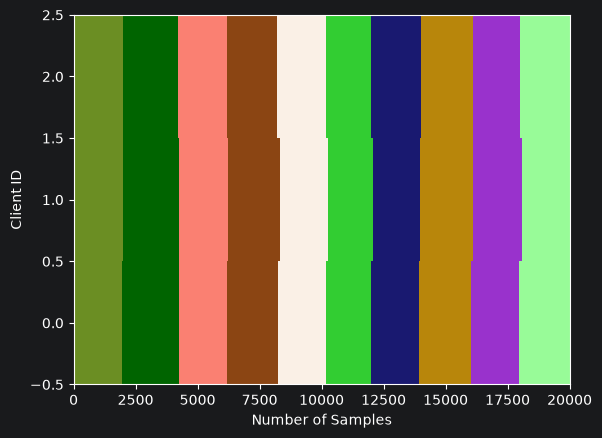

2026-07-24 15:39:10,466 fflow.py init [line:848] INFO PROCESS ID:	7568
2026-07-24 15:39:10,469 fflow.py init [line:849] INFO Initializing devices: cpu will be used for this running.
2026-07-24 15:39:10,470 fflow.py init [line:852] INFO BENCHMARK:	flgo.benchmark.mnist_classification
2026-07-24 15:39:10,471 fflow.py init [line:853] INFO TASK:			./mnist_iid_3
2026-07-24 15:39:10,472 fflow.py init [line:854] INFO MODEL:		flgo.benchmark.mnist_classification.model.cnn
2026-07-24 15:39:10,473 fflow.py init [line:855] INFO ALGORITHM:	fedavg
2026-07-24 15:39:10,508 fflow.py init [line:901] INFO SCENE:		horizontal FL with 1 <class 'flgo.algorithm.fedbase.BasicServer'>, 3 <class 'flgo.algorithm.fedbase.BasicClient'>
2026-07-24 15:39:10,533 fflow.py init [line:918] INFO SIMULATOR:	<class 'flgo.simulator.default_simulator.Simulator'>
2026-07-24 15:39:10,535 fflow.py init [line:931] INFO Ready to start.
2026-07-24 15:39:10,536 fedbase.py run [line:300] INFO --------------Initial Evaluation----------

FLGo: обучение завершено


In [1]:
import flgo
import flgo.algorithm.fedavg as fedavg
from flgo.benchmark.mnist_classification.model import cnn
from flgo.experiment.logger.simple_logger import SimpleLogger
from flgo.benchmark.toolkits.cv.classification import FromDatasetPipe

# Патч совместимости с новым PyTorch: TaskDataset должен уметь __getitems__
def _getitems(self, indices):
    return [self[i] for i in indices]
FromDatasetPipe.TaskDataset.__getitems__ = _getitems

TASK_PATH = "./mnist_iid_3"
task_config = {
    "benchmark":   {"name": "flgo.benchmark.mnist_classification"},
    "partitioner": {"name": "IIDPartitioner", "para": {"num_clients": 3}},
}
flgo.gen_task(task_config, task_path=TASK_PATH)

option = {
    "num_rounds": 5,        # 5 раундов, как в ТЗ
    "proportion": 1.0,      # участвуют все клиенты
    "sample": "full",       # полная выборка (настоящий FedAvg)
    "aggregate": "other",   # взвешенное усреднение по объёму данных
    "num_epochs": 1,        # 1 локальная эпоха
    "batch_size": 128,
    "learning_rate": 0.1,
    "optimizer": "SGD",
    "gpu": [],              # только CPU
    "eval_interval": 1,     # оценка каждый раунд
}
runner = flgo.init(TASK_PATH, fedavg, option, model=cnn, Logger=SimpleLogger)
runner.run()
print("FLGo: обучение завершено")

Доступные ключи логгера: ['option', 'client_datavol', 'time', 'test_accuracy', 'test_loss', 'val_accuracy_dist', 'val_accuracy', 'mean_val_accuracy', 'std_val_accuracy', 'val_loss_dist', 'val_loss', 'mean_val_loss', 'std_val_loss']
FLGo test_accuracy (точка 0 = до обучения): [9.4, 96.09, 97.95, 98.01, 98.54, 98.84]
Разброс по клиентам (std_val_accuracy): [0.0027, 0.0029, 0.0008, 0.0031, 0.0015, 0.0014]


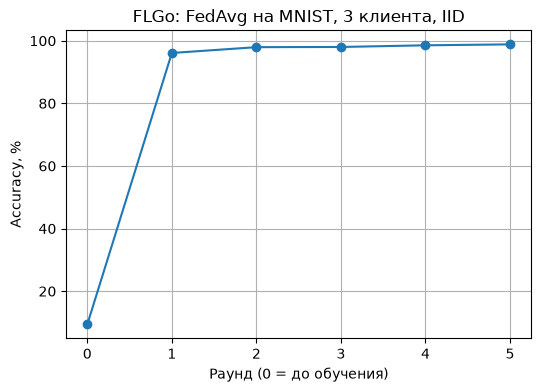

Сохранено: flgo_accuracy.png, flgo_accuracy.csv


In [4]:
import matplotlib.pyplot as plt, csv

try:
    out = runner.gv.logger.output
    print("Доступные ключи логгера:", list(out.keys()))
    test_acc = [round(float(a) * 100, 2) for a in out["test_accuracy"]]
    std_val  = [round(float(s), 4) for s in out.get("std_val_accuracy", [])]
except Exception as e:
    print("logger.output прочитать не вышло:", e, "— беру числа из лога")
    test_acc = [9.40, 96.09, 97.95, 98.01, 98.54, 98.84]
    std_val  = [0.0027, 0.0029, 0.0008, 0.0031, 0.0015, 0.0014]

print("FLGo test_accuracy (точка 0 = до обучения):", test_acc)
print("Разброс по клиентам (std_val_accuracy):", std_val)

rounds = list(range(len(test_acc)))   # 0..5
plt.figure(figsize=(6, 4))
plt.plot(rounds, test_acc, marker="o")
plt.xlabel("Раунд (0 = до обучения)"); plt.ylabel("Accuracy, %")
plt.title("FLGo: FedAvg на MNIST, 3 клиента, IID")
plt.xticks(rounds); plt.grid(True)
plt.savefig("flgo_accuracy.png", dpi=120, bbox_inches="tight")
plt.show()

with open("flgo_accuracy.csv", "w", newline="", encoding="utf-8") as f:
    w = csv.writer(f)
    w.writerow(["round", "test_acc_%", "std_val_acc"])
    for i, a in enumerate(test_acc):
        w.writerow([i, a, std_val[i] if i < len(std_val) else ""])
print("Сохранено: flgo_accuracy.png, flgo_accuracy.csv")